In [1]:
import os
import glob
import numpy as np
import pandas as pd
import geopandas as gpd
import math

import ee
ee.Initialize()
import leafmap
#leafmap.update_package()
import geemap
#geemap.update_package()

In [2]:
out_dir = os.path.join(os.path.expanduser('~'), 'Documents/Calendar/2022/1 January/20/Felipe Bhutan/')
out_dir

'/Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/'

<AxesSubplot:>

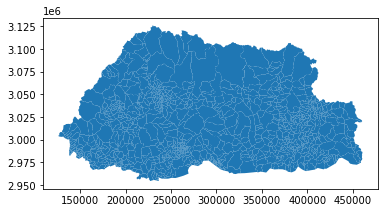

In [3]:
# 1072 chiwogs
shapefile = 'shapes/chiwogs/chiwogs.shp'
chiwogs = gpd.read_file(os.path.join(out_dir,shapefile))
#shapes = geemap.shp_to_ee(os.path.join(out_dir,shapefile))
#shape = chiwogs.dissolve(by='gewogCodeM')
chiwogs.plot()

In [4]:
# Save chiwogs as list of shapes
group = 100
groups = len(chiwogs)/group +1
groups = int(math.ceil(groups))
groups

12

In [5]:
# Save chiwogs as list of shapes
dictOfShapes = {}

low = 1
high = 1 + group
for x in range (1, groups):
    print(x, ':', low, high)
    
    chiwog = chiwogs[(chiwogs["chiwog_row"] >= low) & (chiwogs["chiwog_row"] < high)] 
    #chiwog.plot()
    
    if not os.path.exists("shapes/{}/".format(groups)):
        os.makedirs("shapes/{}/".format(groups))
    
    chiwog.to_file("shapes/{}/{}.shp".format(groups,x))
    
    dictOfShapes["{0}".format(x)] = geemap.shp_to_ee("shapes/{}/{}.shp".format(groups,x), encoding='latin-1')
    
    low = low + group
    high = high + group

1 : 1 101
2 : 101 201
3 : 201 301
4 : 301 401
5 : 401 501
6 : 501 601
7 : 601 701
8 : 701 801
9 : 801 901
10 : 901 1001
11 : 1001 1101


In [6]:
Map = geemap.Map(center = (28, 90), zoom = 7)
Map 

Map(center=[28, 90], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=HBox(children=(Tog…

In [7]:
# Example:
pickCountry = '11'
dictOfShapes[pickCountry]
# Add shapefile
for x in range (1, groups):
    Map.addLayer(dictOfShapes[str(x)], {}, pickCountry)
#Map.centerObject(dictOfShapes[pickCountry])

# Elevation

In [8]:
# Digital elevation models (DEMs) 
srtm = ee.Image('CGIAR/SRTM90_V4').select('elevation')
merit = ee.Image("MERIT/DEM/v1_0_3").select('dem')

#.clip(dictOfShapes[pickCountry])

visualization = {
  'min': -3,
  'max': 4000,
  'palette': ['000000', '478FCD', '86C58E', 'AFC35E', '8F7131',
           'B78D4F', 'E2B8A6', 'FFFFFF']}

# Set visualization parameters for elevation
vis_params = {
  'min': 0,
  'max': 4000,
  'palette': ['006633', 'E5FFCC', '662A00', 'D8D8D8', 'F5F5F5']}

#Map.addLayer(srtm, vis_params, 'SRTM Digital Elevation Data Version 4', True, opacity=1.0)
Map.addLayer(merit, vis_params, "Elevation MERIT")

In [9]:
skip = ['AUS', 'BRA', 'IND', 'RUS']
rerun = ['DOM', 'ERI', 'FRA', 'GAB', 'NGA', 'NLD', 'NZL', 'PAK', 'PLW', 'PYF', 'SLV', 'TZA']

#skip = ['MEX', 'AUS', 'BRA', 'ECU', 'CHL', 'CAN', 'UGA', 'ZAF', 'RUS', 'MDG','THA','IDN', 'IND', 'GNB', 'EST', 'USA']

for iso in range (1, groups):
    print(iso)
    nlcd_stats = os.path.join(out_dir, 'results/elevation/MEAN/MEAN_elevation_{}.csv'.format(iso))  
    if iso not in skip:
        try:
            geemap.zonal_statistics(merit, dictOfShapes["{}".format(iso)], nlcd_stats, statistics_type='MEAN', denominator=1000000, decimal_places=2)
        except:
            print("An exception occurred")
    else:
        print("Skipped")

1
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/elevation/MEAN/MEAN_elevation_1.csv
2
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/elevation/MEAN/MEAN_elevation_2.csv
3
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/elevation/MEAN/MEAN_elevation_3.csv
4
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/elevation/MEAN/MEAN_elevation_4.csv
5
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/elevation/MEAN/MEAN_elevation_5.csv
6
Computing statisti

In [10]:
# 216 countries
os.chdir(os.path.join(os.path.expanduser('~'),"Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/elevation/MEAN/"))
extension = 'csv'
all_filenames = sorted([i for i in glob.glob('*.{}'.format(extension))])
len(all_filenames)

11

In [11]:
elevation_MEAN = pd.concat([pd.read_csv(f) for f in all_filenames])
elevation_MEAN["Elevation"] = elevation_MEAN["mean"]

# Rainfall for 2009

In [12]:
Map = geemap.Map(center = (28, 90), zoom = 7)
Map 

Map(center=[28, 90], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=HBox(children=(Tog…

In [13]:
dataset = ee.ImageCollection('UCSB-CHG/CHIRPS/PENTAD').filter(ee.Filter.date('2009-05-01', '2009-05-05'));
precipitation = dataset.select('precipitation')
precipitationVis = {
  'min': 0.0,
  'max': 112.0,
  'palette': ['001137', '0aab1e', 'e7eb05', 'ff4a2d', 'e90000'],
}
Map.addLayer(precipitation, precipitationVis, 'Precipitation')

In [14]:
CHIRPS_START = '2009-01-01'
CHIRPS_END = '2009-12-31'

skip = ['AUS', 'BRA', 'IND', 'RUS']
rerun = ['DOM', 'ERI', 'FRA', 'GAB', 'NGA', 'NLD', 'NZL', 'PAK', 'PLW', 'PYF', 'SLV', 'TZA']

for iso in range (1, groups):
    
    print(iso)
    chirps_col = ee.ImageCollection('UCSB-CHG/CHIRPS/PENTAD').filter(ee.Filter.date(CHIRPS_START, CHIRPS_END)).select('precipitation').filterBounds(dictOfShapes["{}".format(iso)]).map(lambda image: image.clip(dictOfShapes["{}".format(iso)]))

    nlcd_stats = os.path.join(out_dir, 'results/rainfall/SUM/2009/SUM_rainfall_{}.csv'.format(iso))  
    if iso not in skip:
        try:
            geemap.zonal_statistics(chirps_col, dictOfShapes["{}".format(iso)], nlcd_stats, statistics_type='SUM', denominator=1000000, decimal_places=2)
        except:
            print("An exception occurred")
    else:
        print("Skipped")

1
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/rainfall/SUM/2009/SUM_rainfall_1.csv
2
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/rainfall/SUM/2009/SUM_rainfall_2.csv
3
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/rainfall/SUM/2009/SUM_rainfall_3.csv
4
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/rainfall/SUM/2009/SUM_rainfall_4.csv
5
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/rainfall/SUM/2009/SUM_rainfall_5.csv
6
Computing sta

In [15]:
# 216 countries
os.chdir(os.path.join(os.path.expanduser('~'),"Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/rainfall/SUM/2009/"))
extension = 'csv'
all_filenames = sorted([i for i in glob.glob('*.{}'.format(extension))])
len(all_filenames)

11

In [16]:
rainfall_2009_SUM = pd.concat([pd.read_csv(f) for f in all_filenames])
cols_to_sum = [col for col in rainfall_2009_SUM if col.startswith('2009')]
rainfall_2009_SUM['Rainfall Total 2009'] = rainfall_2009_SUM[cols_to_sum].sum(axis=1)

# Rainfall for 2019


In [17]:
CHIRPS_START = '2019-01-01'
CHIRPS_END = '2019-12-31'

skip = ['AUS', 'BRA', 'IND', 'RUS']
rerun = ['DOM', 'ERI', 'FRA', 'GAB', 'NGA', 'NLD', 'NZL', 'PAK', 'PLW', 'PYF', 'SLV', 'TZA']

for iso in range (1, groups):
    
    print(iso)
    chirps_col = ee.ImageCollection('UCSB-CHG/CHIRPS/PENTAD').filter(ee.Filter.date(CHIRPS_START, CHIRPS_END)).select('precipitation').filterBounds(dictOfShapes["{}".format(iso)]).map(lambda image: image.clip(dictOfShapes["{}".format(iso)]))

    nlcd_stats = os.path.join(out_dir, 'results/rainfall/SUM/2019/SUM_rainfall_{}.csv'.format(iso))  
    if iso not in skip:
        try:
            geemap.zonal_statistics(chirps_col, dictOfShapes["{}".format(iso)], nlcd_stats, statistics_type='SUM', denominator=1000000, decimal_places=2)
        except:
            print("An exception occurred")
    else:
        print("Skipped")

1
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/rainfall/SUM/2019/SUM_rainfall_1.csv
2
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/rainfall/SUM/2019/SUM_rainfall_2.csv
3
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/rainfall/SUM/2019/SUM_rainfall_3.csv
4
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/rainfall/SUM/2019/SUM_rainfall_4.csv
5
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/rainfall/SUM/2019/SUM_rainfall_5.csv
6
Computing sta

In [18]:
# 216 countries
os.chdir(os.path.join(os.path.expanduser('~'),"Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/rainfall/SUM/2019/"))
extension = 'csv'
all_filenames = sorted([i for i in glob.glob('*.{}'.format(extension))])
len(all_filenames)

11

In [19]:
rainfall_2019_SUM = pd.concat([pd.read_csv(f) for f in all_filenames])
cols_to_sum = [col for col in rainfall_2019_SUM if col.startswith('2019')]
rainfall_2019_SUM['Rainfall Total 2019'] = rainfall_2019_SUM[cols_to_sum].sum(axis=1)

# Temperature for 2009

In [20]:
Map = geemap.Map(center = (28, 90), zoom = 7)
Map 

Map(center=[28, 90], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=HBox(children=(Tog…

In [21]:
dataset = ee.ImageCollection('IDAHO_EPSCOR/TERRACLIMATE').filter(ee.Filter.date('2009-07-01', '2009-08-01'))
maximumTemperature = dataset.select('tmmx')
maximumTemperatureVis = {
  'min': -300.0,
  'max': 300.0,
  'palette': [
    '1a3678', '2955bc', '5699ff', '8dbae9', 'acd1ff', 'caebff', 'e5f9ff',
    'fdffb4', 'ffe6a2', 'ffc969', 'ffa12d', 'ff7c1f', 'ca531a', 'ff0000',
    'ab0000'
  ]}

Map.addLayer(maximumTemperature, maximumTemperatureVis, 'Maximum Temperature');

In [22]:
TEMP_START = '2009-01-01'
TEMP_END = '2009-12-31'

skip = ['AUS', 'BRA', 'IND', 'RUS']
rerun = ['DOM', 'ERI', 'FRA', 'GAB', 'NGA', 'NLD', 'NZL', 'PAK', 'PLW', 'PYF', 'SLV', 'TZA']

for iso in range (1, groups):
    
    print(iso)
    chirps_col = ee.ImageCollection('IDAHO_EPSCOR/TERRACLIMATE').filter(ee.Filter.date(TEMP_START, TEMP_END)).select('tmmx').filterBounds(dictOfShapes["{}".format(iso)]).map(lambda image: image.clip(dictOfShapes["{}".format(iso)]))

    nlcd_stats = os.path.join(out_dir, 'results/temperature/MEAN/2009/MEAN_temperature_{}.csv'.format(iso))  
    if iso not in skip:
        try:
            geemap.zonal_statistics(chirps_col, dictOfShapes["{}".format(iso)], nlcd_stats, statistics_type='MEAN', denominator=1000000, decimal_places=2)
        except:
            print("An exception occurred")
    else:
        print("Skipped")

1
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/temperature/MEAN/2009/MEAN_temperature_1.csv
2
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/temperature/MEAN/2009/MEAN_temperature_2.csv
3
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/temperature/MEAN/2009/MEAN_temperature_3.csv
4
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/temperature/MEAN/2009/MEAN_temperature_4.csv
5
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/temperature/MEAN/200

In [23]:
# 216 countries
os.chdir(os.path.join(os.path.expanduser('~'),"Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/temperature/MEAN/2009/"))
extension = 'csv'
all_filenames = sorted([i for i in glob.glob('*.{}'.format(extension))])
len(all_filenames)

11

In [24]:
temperature_2009_MEAN = pd.concat([pd.read_csv(f) for f in all_filenames])
cols_to_sum = [col for col in temperature_2009_MEAN if col.startswith('2009')]
temperature_2009_MEAN['Temp max MEAN 2009'] = temperature_2009_MEAN[cols_to_sum].mean(axis=1)

# Temperature for 2019

In [25]:
Map = geemap.Map(center = (28, 90), zoom = 7)
Map 

Map(center=[28, 90], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=HBox(children=(Tog…

In [26]:
dataset = ee.ImageCollection('IDAHO_EPSCOR/TERRACLIMATE').filter(ee.Filter.date('2019-07-01', '2019-08-01'))
maximumTemperature = dataset.select('tmmx')
maximumTemperatureVis = {
  'min': -300.0,
  'max': 300.0,
  'palette': [
    '1a3678', '2955bc', '5699ff', '8dbae9', 'acd1ff', 'caebff', 'e5f9ff',
    'fdffb4', 'ffe6a2', 'ffc969', 'ffa12d', 'ff7c1f', 'ca531a', 'ff0000',
    'ab0000'
  ]}

Map.addLayer(maximumTemperature, maximumTemperatureVis, 'Maximum Temperature 2019');

In [27]:
TEMP_START = '2019-01-01'
TEMP_END = '2019-12-31'

skip = ['AUS', 'BRA', 'IND', 'RUS']
rerun = ['DOM', 'ERI', 'FRA', 'GAB', 'NGA', 'NLD', 'NZL', 'PAK', 'PLW', 'PYF', 'SLV', 'TZA']

for iso in range (1, groups):
    
    print(iso)
    chirps_col = ee.ImageCollection('IDAHO_EPSCOR/TERRACLIMATE').filter(ee.Filter.date(TEMP_START, TEMP_END)).select('tmmx').filterBounds(dictOfShapes["{}".format(iso)]).map(lambda image: image.clip(dictOfShapes["{}".format(iso)]))

    nlcd_stats = os.path.join(out_dir, 'results/temperature/MEAN/2019/MEAN_temperature_{}.csv'.format(iso))  
    if iso not in skip:
        try:
            geemap.zonal_statistics(chirps_col, dictOfShapes["{}".format(iso)], nlcd_stats, statistics_type='MEAN', denominator=1000000, decimal_places=2)
        except:
            print("An exception occurred")
    else:
        print("Skipped")

1
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/temperature/MEAN/2019/MEAN_temperature_1.csv
2
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/temperature/MEAN/2019/MEAN_temperature_2.csv
3
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/temperature/MEAN/2019/MEAN_temperature_3.csv
4
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/temperature/MEAN/2019/MEAN_temperature_4.csv
5
Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/temperature/MEAN/201

In [28]:
# 216 countries
os.chdir(os.path.join(os.path.expanduser('~'),"Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/temperature/MEAN/2019/"))
extension = 'csv'
all_filenames = sorted([i for i in glob.glob('*.{}'.format(extension))])
len(all_filenames)

11

In [29]:
temperature_2019_MEAN = pd.concat([pd.read_csv(f) for f in all_filenames])
cols_to_sum = [col for col in temperature_2019_MEAN if col.startswith('2019')]
temperature_2019_MEAN['Temp max MEAN 2019'] = temperature_2019_MEAN[cols_to_sum].mean(axis=1)

# Different temperature

In [30]:
Map = geemap.Map(center = (28, 90), zoom = 7)
Map 

Map(center=[28, 90], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=HBox(children=(Tog…

In [31]:
dataset = ee.ImageCollection('MODIS/006/MOD11A2').filter(ee.Filter.date('2019-01-01', '2019-12-31'));
landSurfaceTemperature = dataset.select('LST_Day_1km')

landSurfaceTemperatureVis = {
  'min': 14000.0,
  'max': 16000.0,
  'palette': [
    '040274', '040281', '0502a3', '0502b8', '0502ce', '0502e6',
    '0602ff', '235cb1', '307ef3', '269db1', '30c8e2', '32d3ef',
    '3be285', '3ff38f', '86e26f', '3ae237', 'b5e22e', 'd6e21f',
    'fff705', 'ffd611', 'ffb613', 'ff8b13', 'ff6e08', 'ff500d',
    'ff0000', 'de0101', 'c21301', 'a71001', '911003'
  ],
}
Map.addLayer(landSurfaceTemperature, landSurfaceTemperatureVis,'Land Surface Temperature')

# Maps

In [32]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

Chiwogs = chiwogs.merge(elevation_MEAN[["chiwog_row","Elevation"]], left_on='chiwog_row', right_on='chiwog_row')
Chiwogs = Chiwogs.merge(rainfall_2009_SUM[["chiwog_row","Rainfall Total 2009"]], left_on='chiwog_row', right_on='chiwog_row')
Chiwogs = Chiwogs.merge(rainfall_2019_SUM[["chiwog_row","Rainfall Total 2019"]], left_on='chiwog_row', right_on='chiwog_row')
Chiwogs = Chiwogs.merge(temperature_2009_MEAN[["chiwog_row",'Temp max MEAN 2009']], left_on='chiwog_row', right_on='chiwog_row')
Chiwogs = Chiwogs.merge(temperature_2019_MEAN[["chiwog_row",'Temp max MEAN 2019']], left_on='chiwog_row', right_on='chiwog_row')

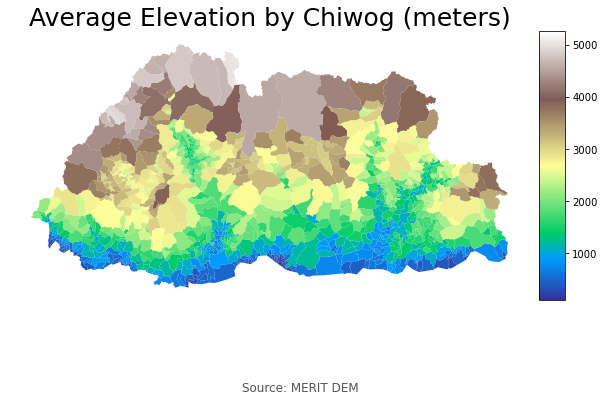

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(20/2,15/2))

ax.axis('off')

divider = make_axes_locatable(ax)

cax = divider.append_axes("right", size="5%", pad=0.1)

Chiwogs.plot(column='Elevation', ax=ax, legend=True, cax=cax, cmap='terrain')

ax.set_title("Average Elevation by Chiwog (meters)", fontdict={'fontsize': '25', 'fontweight' : '3'})
# create an annotation for the data source
ax.annotate("Source: MERIT DEM",xy=(0.4, .08),  xycoords="figure fraction", horizontalalignment="left", verticalalignment="top", fontsize=12, color="#555555")
            
fig.savefig(os.path.join(os.path.expanduser('~'), "Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/map_export_1.png"), dpi=300)  

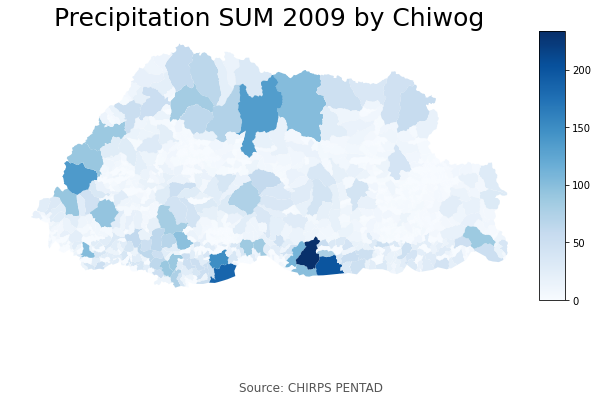

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(20/2,15/2))

ax.axis('off')

divider = make_axes_locatable(ax)

cax = divider.append_axes("right", size="5%", pad=0.1)

Chiwogs.plot(column='Rainfall Total 2009', ax=ax, legend=True, cax=cax, cmap='Blues')

ax.set_title("Precipitation SUM 2009 by Chiwog", fontdict={'fontsize': '25', 'fontweight' : '3'})
# create an annotation for the data source
ax.annotate("Source: CHIRPS PENTAD",xy=(0.4, .08),  xycoords="figure fraction", horizontalalignment="left", verticalalignment="top", fontsize=12, color="#555555")
            
fig.savefig(os.path.join(os.path.expanduser('~'), "Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/map_export_2.png"), dpi=300)   

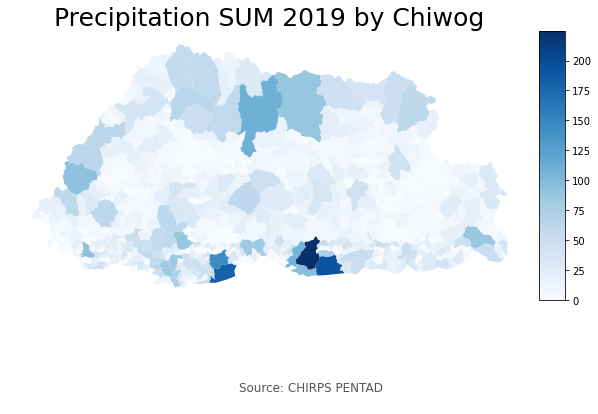

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(20/2,15/2))

ax.axis('off')

divider = make_axes_locatable(ax)

cax = divider.append_axes("right", size="5%", pad=0.1)

Chiwogs.plot(column='Rainfall Total 2019', ax=ax, legend=True, cax=cax, cmap='Blues')

ax.set_title("Precipitation SUM 2019 by Chiwog", fontdict={'fontsize': '25', 'fontweight' : '3'})
# create an annotation for the data source
ax.annotate("Source: CHIRPS PENTAD",xy=(0.4, .08),  xycoords="figure fraction", horizontalalignment="left", verticalalignment="top", fontsize=12, color="#555555")
            
fig.savefig(os.path.join(os.path.expanduser('~'), "Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/map_export_3.png"), dpi=300)  

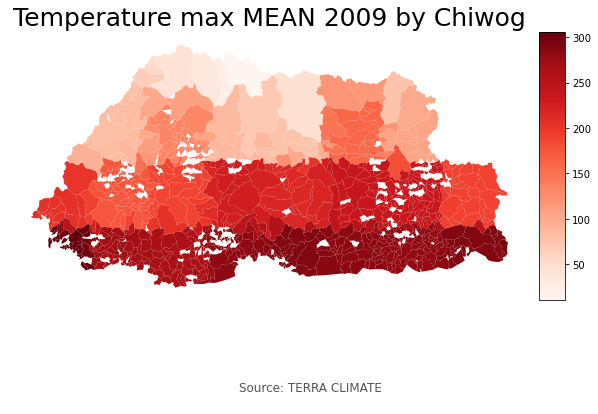

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(20/2,15/2))

ax.axis('off')

divider = make_axes_locatable(ax)

cax = divider.append_axes("right", size="5%", pad=0.1)

Chiwogs.plot(column='Temp max MEAN 2009', ax=ax, legend=True, cax=cax, cmap='Reds')

ax.set_title("Temperature max MEAN 2009 by Chiwog", fontdict={'fontsize': '25', 'fontweight' : '3'})
# create an annotation for the data source
ax.annotate("Source: TERRA CLIMATE",xy=(0.4, .08),  xycoords="figure fraction", horizontalalignment="left", verticalalignment="top", fontsize=12, color="#555555")
            
fig.savefig(os.path.join(os.path.expanduser('~'), "Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/map_export_4.png"), dpi=300)  

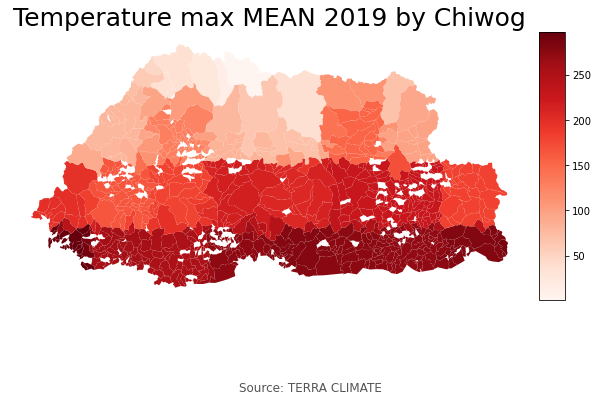

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(20/2,15/2))

ax.axis('off')

divider = make_axes_locatable(ax)

cax = divider.append_axes("right", size="5%", pad=0.1)

Chiwogs.plot(column='Temp max MEAN 2019', ax=ax, legend=True, cax=cax, cmap='Reds')

ax.set_title("Temperature max MEAN 2019 by Chiwog", fontdict={'fontsize': '25', 'fontweight' : '3'})
# create an annotation for the data source
ax.annotate("Source: TERRA CLIMATE",xy=(0.4, .08),  xycoords="figure fraction", horizontalalignment="left", verticalalignment="top", fontsize=12, color="#555555")
            
fig.savefig(os.path.join(os.path.expanduser('~'), "Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/map_export_5.png"), dpi=300)  

In [38]:
cols_out=['chiwog_row', 'Elevation','Rainfall Total 2009', 'Rainfall Total 2019', 'Temp max MEAN 2009','Temp max MEAN 2019']

In [39]:
Chiwogs[cols_out].to_csv(os.path.join(os.path.expanduser('~'), "Documents/Calendar/2022/1 January/20/Felipe Bhutan/results/results data.csv"),index=False)

# Why are some of these empty?

<AxesSubplot:>

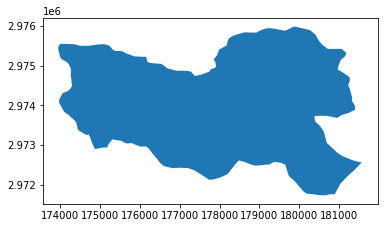

In [40]:
# Try 601
chiwogs_601= chiwogs[chiwogs["chiwog_row"]==601]
chiwogs_601.plot()

In [41]:
chiwogs_601 = geemap.shp_to_ee(os.path.join(os.path.expanduser('~'), "Documents/Calendar/2022/1 January/20/Felipe Bhutan/shapes/1072/601.shp"), encoding='latin-1')

In [42]:
os.chdir(os.path.join(os.path.expanduser('~'),"Documents/Calendar/2022/1 January/20/Felipe Bhutan/"))


geemap.zonal_statistics(chirps_col, chiwogs_601, 'a_601.csv', statistics_type='SUM')



Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /Users/javierparada/Documents/Calendar/2022/1 January/20/Felipe Bhutan/a_601.csv
